In [1]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
from scipy.stats import t
import tqdm

# Set default tensor type for better performance
torch.set_default_dtype(torch.float64)

class TPRegression(nn.Module):
    """
    Implements the sparse Student-t Process regression model using inducing points.
    This is suitable for larger datasets as it avoids the O(N^3) complexity
    by working with an M x M kernel matrix, where M << N.
    """
    def __init__(self, X, y, Z_initial, nu_f=3.0, nu_e=3.0,
                 kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=0.1):
        super().__init__()

        # Data is not a parameter
        self.register_buffer('X', X)
        self.register_buffer('y', y)

        self.N, self.D = X.shape
        self.M = Z_initial.shape[0]

        # --- Hyperparameters and Inducing Points as nn.Parameter ---
        # Z is now a parameter to be optimized
        self.Z = nn.Parameter(Z_initial.clone())

        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance)))
        self.log_likelihood_sigma_sq = nn.Parameter(torch.log(torch.tensor(likelihood_sigma**2)))
        self.log_nu_f = nn.Parameter(torch.log(torch.tensor(nu_f)))
        self.log_nu_e = nn.Parameter(torch.log(torch.tensor(nu_e)))

        # Variational Parameters (not optimized by gradient descent, so not nn.Parameter)
        self.m_u = torch.zeros(self.M, 1)
        self.L_u = torch.eye(self.M)
        self.alpha_r = torch.tensor(1.0)
        self.beta_r = torch.tensor(1.0)
        self.alpha_lambda = torch.ones(self.N, 1)
        self.beta_lambda = torch.ones(self.N, 1)

    def _get_hyperparams(self):
        """Helper to get positive hyperparameters from their log-transformed storage."""
        lengthscale = torch.exp(self.log_kernel_lengthscale)
        variance = torch.exp(self.log_kernel_variance)
        sigma_sq = torch.exp(self.log_likelihood_sigma_sq)
        nu_f = torch.exp(self.log_nu_f)
        nu_e = torch.exp(self.log_nu_e)
        return lengthscale, variance, sigma_sq, nu_f, nu_e

    def kernel(self, A, B):
        """Computes the RBF kernel matrix between A and B."""
        lengthscale, variance, _, _, _ = self._get_hyperparams()
        sq_dist = torch.cdist(A, B, p=2).pow(2)
        return variance * torch.exp(-0.5 * sq_dist / lengthscale.pow(2))

    def _update_q_lambda(self, E_q_f, Var_q_f):
        """CAVI update for q(lambda_i)."""
        _, _, sigma_sq, _, nu_e = self._get_hyperparams()
        self.alpha_lambda = nu_e / 2.0 + 0.5
        expected_sq_error = (self.y - E_q_f).pow(2) + Var_q_f
        self.beta_lambda = nu_e / 2.0 + (1.0 / (2.0 * sigma_sq)) * expected_sq_error

    def _update_q_r(self, E_quad_form_u):
        """CAVI update for q(r)."""
        _, _, _, nu_f, _ = self._get_hyperparams()
        self.alpha_r = nu_f / 2.0 + self.M / 2.0
        self.beta_r = nu_f / 2.0 + 0.5 * E_quad_form_u.squeeze()

    def _update_q_u(self, Kzz, Lzz, Kxz):
        """CAVI update for q(u)."""
        _, _, sigma_sq, _, _ = self._get_hyperparams()
        E_r = self.alpha_r / self.beta_r
        E_lambda = self.alpha_lambda / self.beta_lambda

        Psi = Kxz.T @ (E_lambda * Kxz) / sigma_sq
        B = E_r * Kzz + Psi
        L_B = torch.linalg.cholesky(B)

        Kzz_invB_Kzz = torch.cholesky_solve(Kzz, L_B)
        S_u = Kzz @ Kzz_invB_Kzz
        S_u = 0.5 * (S_u + S_u.T) # Ensure symmetry
        self.L_u = torch.linalg.cholesky(S_u + torch.eye(self.M) * 1e-6)

        temp_vec = (Kxz.T * E_lambda.T) @ self.y / sigma_sq
        m_u_unscaled = torch.cholesky_solve(temp_vec, L_B)
        self.m_u = Kzz @ m_u_unscaled

    def _cavi_step(self, Kzz, Lzz, Kxz, Kxx_diag, cavi_max_iter=10, cavi_tol=1e-5):
        """Runs the inner CAVI loop until convergence for fixed hyperparameters."""
        for _ in range(cavi_max_iter):
            m_u_old = self.m_u.clone()

            # Required expectations for updates
            Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
            E_q_f = Kxz @ Kzz_inv_mu

            E_inv_r = self.beta_r / (self.alpha_r - 1) if self.alpha_r > 1 else self.beta_r

            A = torch.linalg.solve(Kzz, Kxz.T).T
            var_f_inducing = torch.sum((A @ self.L_u)**2, dim=1)
            var_f_prior = E_inv_r * (Kxx_diag - torch.sum(A * Kxz, dim=1))
            Var_q_f = (var_f_prior + var_f_inducing).unsqueeze(1)

            S_u = self.L_u @ self.L_u.T
            Kzz_inv_Su = torch.cholesky_solve(S_u, Lzz)
            trace_term = torch.trace(Kzz_inv_Su)
            quad_form_term = self.m_u.T @ Kzz_inv_mu
            E_quad_form_u = trace_term + quad_form_term

            # CAVI updates
            self._update_q_lambda(E_q_f, Var_q_f)
            self._update_q_r(E_quad_form_u)
            self._update_q_u(Kzz, Lzz, Kxz)

            change = torch.norm(self.m_u - m_u_old) / (torch.norm(m_u_old) + 1e-9)
            if change < cavi_tol:
                break

    def calculate_elbo(self):
        """
        Calculates the Evidence Lower Bound (ELBO).
        This method uses self.Z, self.X, so it's compatible with Z being a parameter.
        It's important that kernel() is called inside, as it will use the current self.Z.
        """
        lengthscale, variance, sigma_sq, nu_f, nu_e = self._get_hyperparams()

        Kzz = self.kernel(self.Z, self.Z) + torch.eye(self.M) * 1e-6
        Lzz = torch.linalg.cholesky(Kzz)
        Kxz = self.kernel(self.X, self.Z)
        Kxx_diag = self.kernel(self.X, self.X).diag()

        # --- 1. Expected Log Likelihood ---
        Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
        E_q_f = Kxz @ Kzz_inv_mu

        E_inv_r = self.beta_r / (self.alpha_r - 1) if self.alpha_r > 1 else self.beta_r

        A = torch.linalg.solve(Kzz, Kxz.T).T
        var_f_inducing = torch.sum((A @ self.L_u)**2, dim=1)
        var_f_prior = E_inv_r * (Kxx_diag - torch.sum(A * Kxz, dim=1))
        Var_q_f = (var_f_prior + var_f_inducing).unsqueeze(1)

        expected_sq_error = (self.y - E_q_f).pow(2) + Var_q_f

        E_lambda = self.alpha_lambda / self.beta_lambda
        E_log_lambda = torch.digamma(self.alpha_lambda) - torch.log(self.beta_lambda)

        e_log_lik = -0.5 * self.N * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * self.N * torch.log(sigma_sq) + \
                    0.5 * torch.sum(E_log_lambda) - \
                    0.5 / sigma_sq * torch.sum(E_lambda * expected_sq_error)

        # --- 2. KL Divergence for u and r ---
        S_u = self.L_u @ self.L_u.T
        E_r = self.alpha_r / self.beta_r
        E_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)

        log_q_u = -0.5 * self.M * torch.log(torch.tensor(2 * torch.pi)) - torch.sum(torch.log(torch.diag(self.L_u))) - 0.5 * self.M
        
        log_q_r = self.alpha_r * torch.log(self.beta_r) - torch.lgamma(self.alpha_r) + \
                  (self.alpha_r - 1) * E_log_r - self.beta_r * E_r

        E_quad_form_u = torch.trace(torch.cholesky_solve(S_u, Lzz)) + self.m_u.T @ torch.cholesky_solve(self.m_u, Lzz)
        log_det_Kzz = 2 * torch.sum(torch.log(torch.diag(Lzz)))
        log_p_u_r = -0.5 * self.M * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * log_det_Kzz + \
                     0.5 * self.M * E_log_r - 0.5 * E_r * E_quad_form_u

        log_p_r = (nu_f / 2) * torch.log(nu_f / 2) - torch.lgamma(nu_f / 2) + \
                  (nu_f / 2 - 1) * E_log_r - (nu_f / 2) * E_r

        kl_u_r = log_q_u + log_q_r - log_p_u_r - log_p_r

        # --- 3. KL Divergence for lambda_i ---
        kl_lambda = torch.lgamma(self.alpha_lambda) - self.alpha_lambda * torch.log(self.beta_lambda) - \
                    (torch.lgamma(nu_e / 2) - (nu_e / 2) * torch.log(nu_e / 2)) - \
                    (self.alpha_lambda - nu_e / 2) * E_log_lambda + \
                    (self.beta_lambda - nu_e / 2) * E_lambda

        kl_lambda_sum = torch.sum(kl_lambda)

        elbo = e_log_lik - kl_u_r - kl_lambda_sum
        return elbo

    def fit(self, max_iter_global=50, max_iter_local=1, lr=0.01, cavi_max_iter=10, cavi_tol=1e-5):
        """
        Fits the model by jointly optimizing hyperparameters and inducing points (M-step)
        and updating variational parameters (E-step).
        Returns the history of ELBO values.
        """
        elbo_history = [] # ADDED: To store ELBO values

        print("Starting optimization with hyperparameter AND inducing point updates...")
        pbar = tqdm.trange(max_iter_global)
        for i in pbar:
            # --- E-Step: Update variational parameters with fixed hypers/Z ---
            # K matrices are computed once before CAVI, as Z and hypers are fixed during E-step.
            with torch.no_grad():
                Kzz = self.kernel(self.Z, self.Z) + torch.eye(self.M) * 1e-6
                Lzz = torch.linalg.cholesky(Kzz)
                Kxz = self.kernel(self.X, self.Z)
                Kxx_diag = self.kernel(self.X, self.X).diag()
                self._cavi_step(Kzz, Lzz, Kxz, Kxx_diag, cavi_max_iter, cavi_tol)

            optimizer = torch.optim.Adam(self.parameters(), lr=lr)
            for j in range(max_iter_local):
                # --- M-Step: Update hyperparameters and Z by maximizing ELBO ---
                optimizer.zero_grad()
                # ELBO is calculated with current parameters (including Z) to get gradients
                neg_elbo = -self.calculate_elbo()
                neg_elbo.backward()
                optimizer.step()

                # ADDED: Store ELBO for plotting
                current_elbo = -neg_elbo.item()
                elbo_history.append(current_elbo)
                pbar.set_description(f"ELBO: {current_elbo:.2f}")
        
        return elbo_history # ADDED: Return the history

    def predict(self, X_test):
        """Make predictions at new test points X_test."""
        with torch.no_grad():
            # We use .detach() on Z as we don't want prediction to be part of the computation graph.
            Z_final = self.Z
            K_star_z = self.kernel(X_test, Z_final)
            K_star_star_diag = self.kernel(X_test, X_test).diag()
            Kzz = self.kernel(Z_final, Z_final) + torch.eye(self.M) * 1e-6
            Lzz = torch.linalg.cholesky(Kzz)

            # Predictive Mean
            Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
            pred_mean = K_star_z @ Kzz_inv_mu

            # Predictive Variance
            S_u = self.L_u @ self.L_u.T
            A_star = torch.linalg.solve(Kzz, K_star_z.T).T
            var_from_q_u = torch.sum((A_star @ self.L_u)**2, dim=1)

            E_inv_r = self.beta_r / (self.alpha_r - 1.0) if self.alpha_r > 1 else self.beta_r
            var_from_prior = E_inv_r * (K_star_star_diag - torch.sum(A_star * K_star_z, dim=1))

            pred_var = var_from_prior + var_from_q_u
            
            # Predictive degrees of freedom
            pred_nu = 2 * self.alpha_r

            return pred_mean.detach(), pred_var.unsqueeze(1).detach(), pred_nu.detach()

Starting optimization with hyperparameter AND inducing point updates...


ELBO: -143.61: 100%|██████████| 1000/1000 [00:04<00:00, 242.62it/s]



--- Initial Z ---
[-5.         -4.47368421 -3.94736842 -3.42105263 -2.89473684 -2.36842105
 -1.84210526 -1.31578947 -0.78947368 -0.26315789  0.26315789  0.78947368
  1.31578947  1.84210526  2.36842105  2.89473684  3.42105263  3.94736842
  4.47368421  5.        ]

--- Optimized Z ---
[-5.0408497  -4.3135589  -4.28900986 -3.22164321 -3.21543563 -2.25002944
 -1.72039632 -1.71534327 -0.53133248 -0.54166259  0.72666854  0.72330429
  1.95691931  1.93955068  3.38888296  2.28881514  3.38110193  4.48810099
  4.49318408  5.31970408]
-------------------


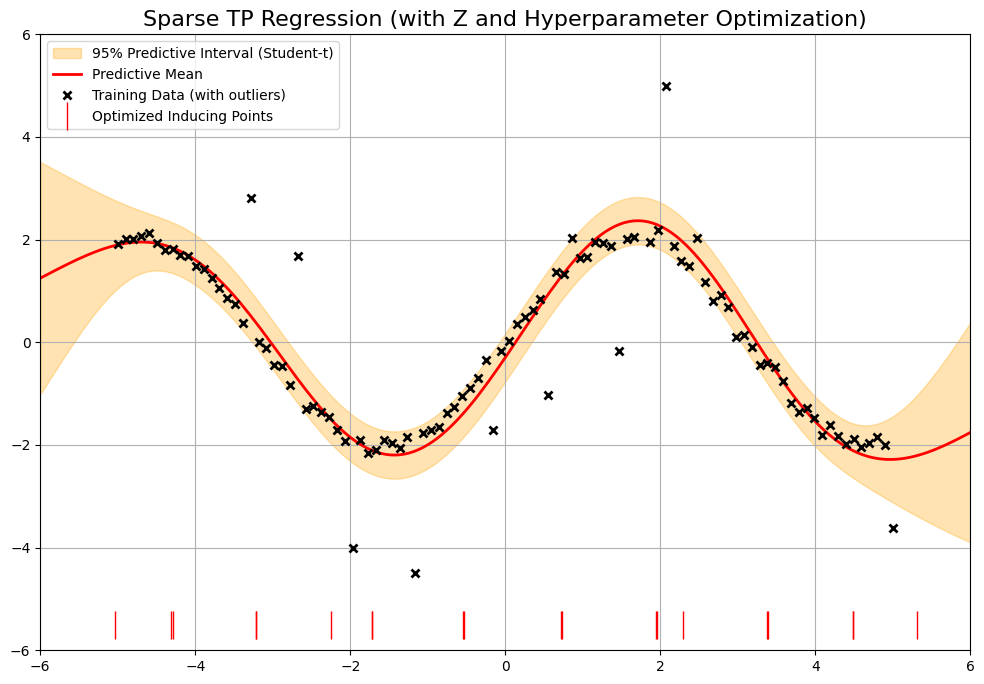

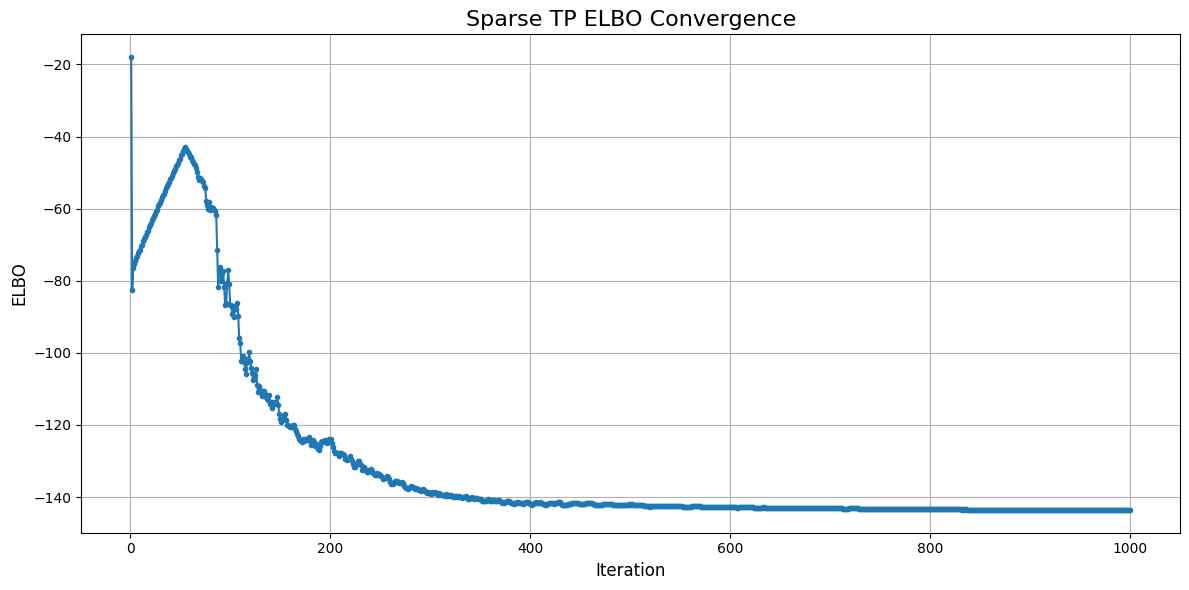

In [8]:

if __name__ == '__main__':
    # 1. Generate data
    N = 100
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    noise = torch.randn(N, 1) * 0.1
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N, 1)) * 0.5
    y_train = y_true + noise
    outlier_indices = torch.randperm(N)[:10]
    y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
    y_train[30] = -4.0
    y_train[70] = 5.0

    # 2. Setup the model with INITIAL inducing points
    M = 20
    Z_initial = torch.linspace(-5, 5, M).unsqueeze(1)

    model = TPRegression(
        X=X_train,
        y=y_train,
        Z_initial=Z_initial,
        nu_f=5.0,
        nu_e=5.0,
        kernel_lengthscale=0.5,
        kernel_variance=2.0,
        likelihood_sigma=0.5
    )

    # 3. Fit the model and get ELBO history
    # MODIFIED: Capture the returned elbo_history
    elbo_history = model.fit(max_iter_global=1000, max_iter_local=1, lr=0.01, cavi_max_iter=1)

    # Print final Z locations
    print("\n--- Initial Z ---")
    print(Z_initial.squeeze().numpy())
    print("\n--- Optimized Z ---")
    print(model.Z.detach().squeeze().numpy())
    print("-------------------")

    # 4. Make predictions
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # 5. Visualize the regression results
    plt.figure(figsize=(12, 8))

    pred_scale = torch.sqrt(pred_var.clamp(min=1e-9))
    df = pred_nu.item()
    lower_quantile = t.ppf(0.025, df=df)
    upper_quantile = t.ppf(0.975, df=df)
    lower = pred_mean + lower_quantile * pred_scale
    upper = pred_mean + upper_quantile * pred_scale

    plt.fill_between(X_test.squeeze(), lower.squeeze(), upper.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval (Student-t)')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data (with outliers)')

    # Plot final optimized inducing points
    plt.plot(model.Z.detach(), torch.full_like(model.Z.detach(), -5.5), 'r|', ms=20, label='Optimized Inducing Points')

    plt.title('Sparse TP Regression (with Z and Hyperparameter Optimization)', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    # 6. ADDED: Visualize ELBO history
    plt.figure(figsize=(12, 6))
    plt.plot(range(1, len(elbo_history) + 1), elbo_history, marker='.', linestyle='-')
    plt.title('Sparse TP ELBO Convergence', fontsize=16)
    plt.xlabel('Iteration', fontsize=12)
    plt.ylabel('ELBO', fontsize=12)
    plt.grid(True)
    plt.tight_layout()

    plt.show()


In [1]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
from scipy.stats import t
import tqdm

# Set default tensor type for better performance
torch.set_default_dtype(torch.float64)

class TPRegression(nn.Module):
    """
    Implements the sparse Student-t Process regression model using inducing points.
    This is suitable for larger datasets as it avoids the O(N^3) complexity
    by working with an M x M kernel matrix, where M << N.
    """
    def __init__(self, X, y, Z_initial, nu_f=3.0, nu_e=3.0,
                 kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=0.1):
        super().__init__()

        # Data is not a parameter
        self.register_buffer('X', X)
        self.register_buffer('y', y)

        self.N, self.D = X.shape
        self.M = Z_initial.shape[0]

        # --- Hyperparameters and Inducing Points as nn.Parameter ---
        # Z is now a parameter to be optimized
        self.Z = nn.Parameter(Z_initial.clone())

        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance)))
        self.log_likelihood_sigma_sq = nn.Parameter(torch.log(torch.tensor(likelihood_sigma**2)))
        self.log_nu_f = nn.Parameter(torch.log(torch.tensor(nu_f)))
        self.log_nu_e = nn.Parameter(torch.log(torch.tensor(nu_e)))

        # Variational Parameters (not optimized by gradient descent, so not nn.Parameter)
        self.m_u = torch.zeros(self.M, 1)
        self.L_u = torch.eye(self.M)
        self.alpha_r = torch.tensor(1.0)
        self.beta_r = torch.tensor(1.0)
        self.alpha_lambda = torch.ones(self.N, 1)
        self.beta_lambda = torch.ones(self.N, 1)

    def _get_hyperparams(self):
        """Helper to get positive hyperparameters from their log-transformed storage."""
        lengthscale = torch.exp(self.log_kernel_lengthscale)
        variance = torch.exp(self.log_kernel_variance)
        sigma_sq = torch.exp(self.log_likelihood_sigma_sq)
        nu_f = torch.exp(self.log_nu_f)
        nu_e = torch.exp(self.log_nu_e)
        return lengthscale, variance, sigma_sq, nu_f, nu_e

    def kernel(self, A, B):
        """Computes the RBF kernel matrix between A and B."""
        lengthscale, variance, _, _, _ = self._get_hyperparams()
        sq_dist = torch.cdist(A, B, p=2).pow(2)
        return variance * torch.exp(-0.5 * sq_dist / lengthscale.pow(2))

    def _update_q_lambda(self, E_q_f, Var_q_f):
        """CAVI update for q(lambda_i)."""
        _, _, sigma_sq, _, nu_e = self._get_hyperparams()
        self.alpha_lambda = nu_e / 2.0 + 0.5
        expected_sq_error = (self.y - E_q_f).pow(2) + Var_q_f
        self.beta_lambda = nu_e / 2.0 + (1.0 / (2.0 * sigma_sq)) * expected_sq_error

    def _update_q_r(self, E_quad_form_u):
        """CAVI update for q(r)."""
        _, _, _, nu_f, _ = self._get_hyperparams()
        self.alpha_r = nu_f / 2.0 + self.M / 2.0
        self.beta_r = nu_f / 2.0 + 0.5 * E_quad_form_u.squeeze()

    def _update_q_u(self, Kzz, Lzz, Kxz):
        """CAVI update for q(u)."""
        _, _, sigma_sq, _, _ = self._get_hyperparams()
        E_r = self.alpha_r / self.beta_r
        E_lambda = self.alpha_lambda / self.beta_lambda

        Psi = Kxz.T @ (E_lambda * Kxz) / sigma_sq
        B = E_r * Kzz + Psi
        L_B = torch.linalg.cholesky(B)

        Kzz_invB_Kzz = torch.cholesky_solve(Kzz, L_B)
        S_u = Kzz @ Kzz_invB_Kzz
        S_u = 0.5 * (S_u + S_u.T) # Ensure symmetry
        self.L_u = torch.linalg.cholesky(S_u + torch.eye(self.M) * 1e-6)

        temp_vec = (Kxz.T * E_lambda.T) @ self.y / sigma_sq
        m_u_unscaled = torch.cholesky_solve(temp_vec, L_B)
        self.m_u = Kzz @ m_u_unscaled

    def _cavi_step(self, Kzz, Lzz, Kxz, Kxx_diag, cavi_max_iter=10, cavi_tol=1e-5):
        """Runs the inner CAVI loop until convergence for fixed hyperparameters."""
        for _ in range(cavi_max_iter):
            m_u_old = self.m_u.clone()

            # Required expectations for updates
            Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
            E_q_f = Kxz @ Kzz_inv_mu

            E_inv_r = self.beta_r / (self.alpha_r - 1) if self.alpha_r > 1 else self.beta_r

            A = torch.linalg.solve(Kzz, Kxz.T).T
            var_f_inducing = torch.sum((A @ self.L_u)**2, dim=1)
            var_f_prior = E_inv_r * (Kxx_diag - torch.sum(A * Kxz, dim=1))
            Var_q_f = (var_f_prior + var_f_inducing).unsqueeze(1)

            S_u = self.L_u @ self.L_u.T
            Kzz_inv_Su = torch.cholesky_solve(S_u, Lzz)
            trace_term = torch.trace(Kzz_inv_Su)
            quad_form_term = self.m_u.T @ Kzz_inv_mu
            E_quad_form_u = trace_term + quad_form_term

            # CAVI updates
            self._update_q_lambda(E_q_f, Var_q_f)
            self._update_q_r(E_quad_form_u)
            self._update_q_u(Kzz, Lzz, Kxz)

            change = torch.norm(self.m_u - m_u_old) / (torch.norm(m_u_old) + 1e-9)
            if change < cavi_tol:
                break

    def calculate_elbo(self):
        """
        Calculates the Evidence Lower Bound (ELBO).
        This method uses self.Z, self.X, so it's compatible with Z being a parameter.
        It's important that kernel() is called inside, as it will use the current self.Z.
        """
        lengthscale, variance, sigma_sq, nu_f, nu_e = self._get_hyperparams()

        Kzz = self.kernel(self.Z, self.Z) + torch.eye(self.M) * 1e-6
        Lzz = torch.linalg.cholesky(Kzz)
        Kxz = self.kernel(self.X, self.Z)
        Kxx_diag = self.kernel(self.X, self.X).diag()

        # --- 1. Expected Log Likelihood ---
        Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
        E_q_f = Kxz @ Kzz_inv_mu

        E_inv_r = self.beta_r / (self.alpha_r - 1) if self.alpha_r > 1 else self.beta_r

        A = torch.linalg.solve(Kzz, Kxz.T).T
        var_f_inducing = torch.sum((A @ self.L_u)**2, dim=1)
        var_f_prior = E_inv_r * (Kxx_diag - torch.sum(A * Kxz, dim=1))
        Var_q_f = (var_f_prior + var_f_inducing).unsqueeze(1)

        expected_sq_error = (self.y - E_q_f).pow(2) + Var_q_f

        E_lambda = self.alpha_lambda / self.beta_lambda
        E_log_lambda = torch.digamma(self.alpha_lambda) - torch.log(self.beta_lambda)

        e_log_lik = -0.5 * self.N * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * self.N * torch.log(sigma_sq) + \
                    0.5 * torch.sum(E_log_lambda) - \
                    0.5 / sigma_sq * torch.sum(E_lambda * expected_sq_error)

        # --- 2. KL Divergence for u and r ---
        S_u = self.L_u @ self.L_u.T
        E_r = self.alpha_r / self.beta_r
        E_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)

        log_q_u = -0.5 * self.M * torch.log(torch.tensor(2 * torch.pi)) - torch.sum(torch.log(torch.diag(self.L_u))) - 0.5 * self.M
        
        log_q_r = self.alpha_r * torch.log(self.beta_r) - torch.lgamma(self.alpha_r) + \
                  (self.alpha_r - 1) * E_log_r - self.beta_r * E_r

        E_quad_form_u = torch.trace(torch.cholesky_solve(S_u, Lzz)) + self.m_u.T @ torch.cholesky_solve(self.m_u, Lzz)
        log_det_Kzz = 2 * torch.sum(torch.log(torch.diag(Lzz)))
        log_p_u_r = -0.5 * self.M * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * log_det_Kzz + \
                     0.5 * self.M * E_log_r - 0.5 * E_r * E_quad_form_u

        log_p_r = (nu_f / 2) * torch.log(nu_f / 2) - torch.lgamma(nu_f / 2) + \
                  (nu_f / 2 - 1) * E_log_r - (nu_f / 2) * E_r

        kl_u_r = log_q_u + log_q_r - log_p_u_r - log_p_r

        # --- 3. KL Divergence for lambda_i ---
        kl_lambda = torch.lgamma(self.alpha_lambda) - self.alpha_lambda * torch.log(self.beta_lambda) - \
                    (torch.lgamma(nu_e / 2) - (nu_e / 2) * torch.log(nu_e / 2)) - \
                    (self.alpha_lambda - nu_e / 2) * E_log_lambda + \
                    (self.beta_lambda - nu_e / 2) * E_lambda

        kl_lambda_sum = torch.sum(kl_lambda)

        elbo = e_log_lik - kl_u_r - kl_lambda_sum
        return elbo

    def fit(self, max_iter_global=50, max_iter_local=1, lr=0.01, cavi_max_iter=10, cavi_tol=1e-5):
        """
        Fits the model by jointly optimizing hyperparameters and inducing points (M-step)
        and updating variational parameters (E-step).
        Returns the history of ELBO values.
        """
        elbo_history = [] # ADDED: To store ELBO values

        print("Starting optimization with hyperparameter AND inducing point updates...")
        pbar = tqdm.trange(max_iter_global)
        for i in pbar:
            # --- E-Step: Update variational parameters with fixed hypers/Z ---
            # K matrices are computed once before CAVI, as Z and hypers are fixed during E-step.
            with torch.no_grad():
                Kzz = self.kernel(self.Z, self.Z) + torch.eye(self.M) * 1e-6
                Lzz = torch.linalg.cholesky(Kzz)
                Kxz = self.kernel(self.X, self.Z)
                Kxx_diag = self.kernel(self.X, self.X).diag()
                self._cavi_step(Kzz, Lzz, Kxz, Kxx_diag, cavi_max_iter, cavi_tol)

            optimizer = torch.optim.Adam(self.parameters(), lr=lr)
            for j in range(max_iter_local):
                # --- M-Step: Update hyperparameters and Z by maximizing ELBO ---
                optimizer.zero_grad()
                # ELBO is calculated with current parameters (including Z) to get gradients
                neg_elbo = -self.calculate_elbo()
                neg_elbo.backward()
                optimizer.step()

                # ADDED: Store ELBO for plotting
                current_elbo = -neg_elbo.item()
                elbo_history.append(current_elbo)
                pbar.set_description(f"ELBO: {current_elbo:.2f}")
        
        return elbo_history # ADDED: Return the history

    def predict(self, X_test):
        """Make predictions at new test points X_test."""
        with torch.no_grad():
            # We use .detach() on Z as we don't want prediction to be part of the computation graph.
            Z_final = self.Z
            K_star_z = self.kernel(X_test, Z_final)
            K_star_star_diag = self.kernel(X_test, X_test).diag()
            Kzz = self.kernel(Z_final, Z_final) + torch.eye(self.M) * 1e-6
            Lzz = torch.linalg.cholesky(Kzz)

            # Predictive Mean
            Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
            pred_mean = K_star_z @ Kzz_inv_mu

            # Predictive Variance
            S_u = self.L_u @ self.L_u.T
            A_star = torch.linalg.solve(Kzz, K_star_z.T).T
            var_from_q_u = torch.sum((A_star @ self.L_u)**2, dim=1)

            E_inv_r = self.beta_r / (self.alpha_r - 1.0) if self.alpha_r > 1 else self.beta_r
            var_from_prior = E_inv_r * (K_star_star_diag - torch.sum(A_star * K_star_z, dim=1))

            pred_var = var_from_prior + var_from_q_u
            
            # Predictive degrees of freedom
            pred_nu = 2 * self.alpha_r

            return pred_mean.detach(), pred_var.unsqueeze(1).detach(), pred_nu.detach()

Starting optimization with hyperparameter AND inducing point updates...


ELBO: -164.09: 100%|██████████| 50/50 [00:01<00:00, 26.67it/s]



--- Initial Z ---
[-5.         -4.47368421 -3.94736842 -3.42105263 -2.89473684 -2.36842105
 -1.84210526 -1.31578947 -0.78947368 -0.26315789  0.26315789  0.78947368
  1.31578947  1.84210526  2.36842105  2.89473684  3.42105263  3.94736842
  4.47368421  5.        ]

--- Optimized Z ---
[-5.9859106  -5.40746211 -4.86641693 -4.30188557 -3.57938359 -2.68380583
 -2.39950548 -1.95288868 -1.26539713 -0.3016826   0.29194541  0.94287207
  1.5246549   1.87424841  2.17466223  3.31468983  3.73079447  4.65447468
  5.20836334  5.87336725]
-------------------


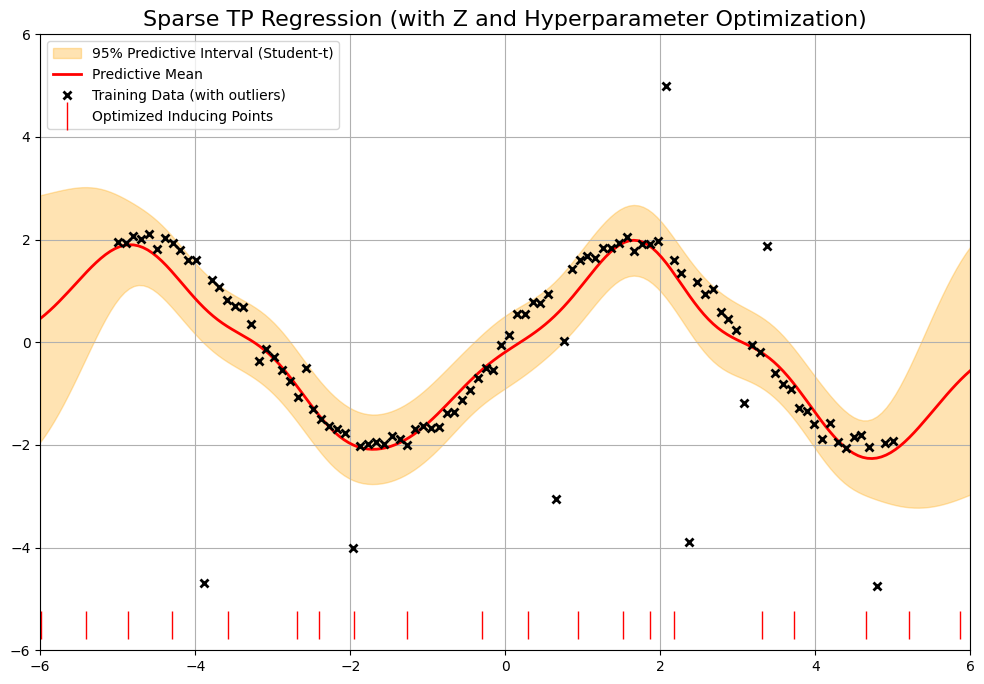

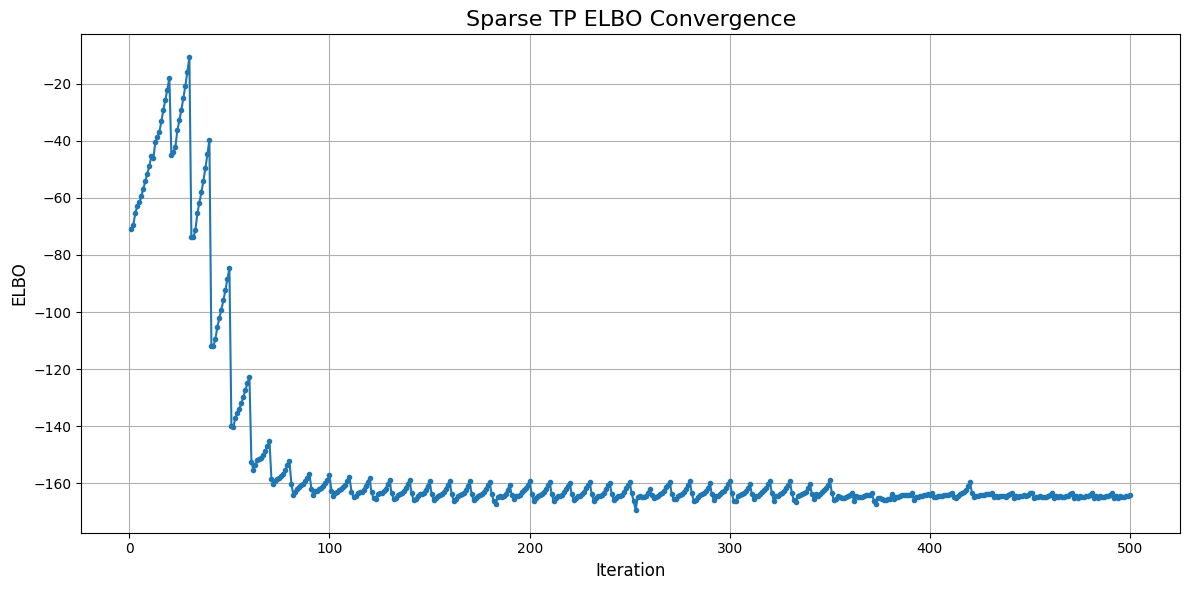

In [3]:

if __name__ == '__main__':
    # 1. Generate data
    N = 100
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    noise = torch.randn(N, 1) * 0.1
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N, 1)) * 0.5
    y_train = y_true + noise
    outlier_indices = torch.randperm(N)[:10]
    y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
    y_train[30] = -4.0
    y_train[70] = 5.0

    # 2. Setup the model with INITIAL inducing points
    M = 20
    Z_initial = torch.linspace(-5, 5, M).unsqueeze(1)

    model = TPRegression(
        X=X_train,
        y=y_train,
        Z_initial=Z_initial,
        nu_f=5.0,
        nu_e=5.0,
        kernel_lengthscale=0.5,
        kernel_variance=2.0,
        likelihood_sigma=0.5
    )

    # 3. Fit the model and get ELBO history
    # MODIFIED: Capture the returned elbo_history
    elbo_history = model.fit(max_iter_global=50, max_iter_local=10, lr=0.05, cavi_max_iter=200)

    # Print final Z locations
    print("\n--- Initial Z ---")
    print(Z_initial.squeeze().numpy())
    print("\n--- Optimized Z ---")
    print(model.Z.detach().squeeze().numpy())
    print("-------------------")

    # 4. Make predictions
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # 5. Visualize the regression results
    plt.figure(figsize=(12, 8))

    pred_scale = torch.sqrt(pred_var.clamp(min=1e-9))
    df = pred_nu.item()
    lower_quantile = t.ppf(0.025, df=df)
    upper_quantile = t.ppf(0.975, df=df)
    lower = pred_mean + lower_quantile * pred_scale
    upper = pred_mean + upper_quantile * pred_scale

    plt.fill_between(X_test.squeeze(), lower.squeeze(), upper.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval (Student-t)')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data (with outliers)')

    # Plot final optimized inducing points
    plt.plot(model.Z.detach(), torch.full_like(model.Z.detach(), -5.5), 'r|', ms=20, label='Optimized Inducing Points')

    plt.title('Sparse TP Regression (with Z and Hyperparameter Optimization)', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    # 6. ADDED: Visualize ELBO history
    plt.figure(figsize=(12, 6))
    plt.plot(range(1, len(elbo_history) + 1), elbo_history, marker='.', linestyle='-')
    plt.title('Sparse TP ELBO Convergence', fontsize=16)
    plt.xlabel('Iteration', fontsize=12)
    plt.ylabel('ELBO', fontsize=12)
    plt.grid(True)
    plt.tight_layout()

    plt.show()


Starting optimization with hyperparameter updates (Z is fixed)...


ELBO: -2.39:   0%|          | 0/2 [00:00<?, ?it/s] 

ELBO: 125721.64: 100%|██████████| 2/2 [00:00<00:00,  2.42it/s]



--- Initial Z ---
[-5.         -4.47368421 -3.94736842 -3.42105263 -2.89473684 -2.36842105
 -1.84210526 -1.31578947 -0.78947368 -0.26315789  0.26315789  0.78947368
  1.31578947  1.84210526  2.36842105  2.89473684  3.42105263  3.94736842
  4.47368421  5.        ]

--- Final Z (Fixed) ---
[-5.         -4.47368421 -3.94736842 -3.42105263 -2.89473684 -2.36842105
 -1.84210526 -1.31578947 -0.78947368 -0.26315789  0.26315789  0.78947368
  1.31578947  1.84210526  2.36842105  2.89473684  3.42105263  3.94736842
  4.47368421  5.        ]
-------------------


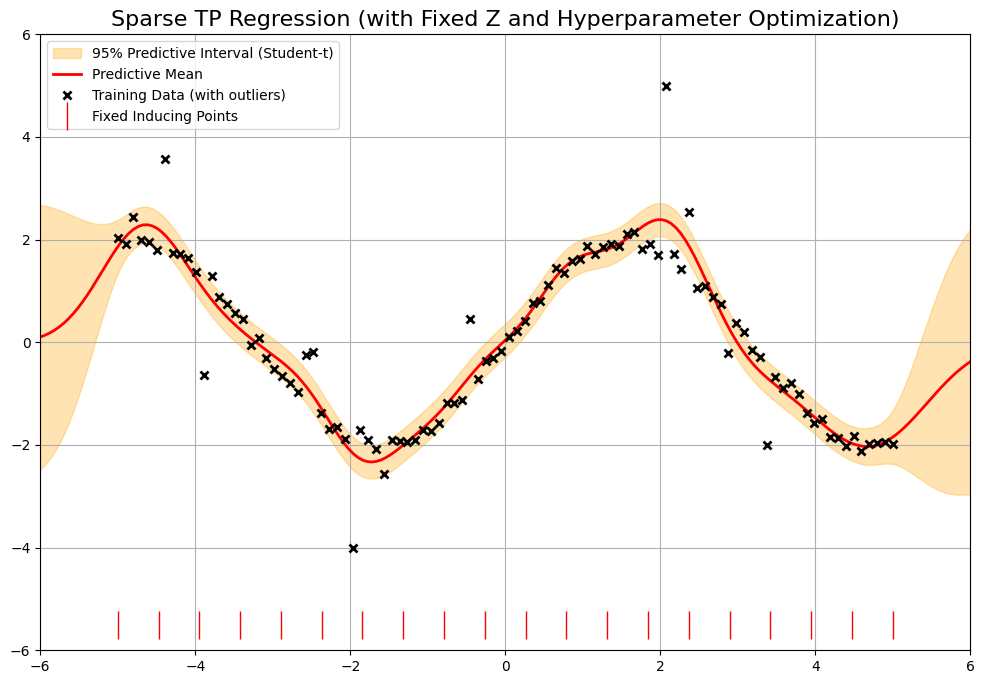

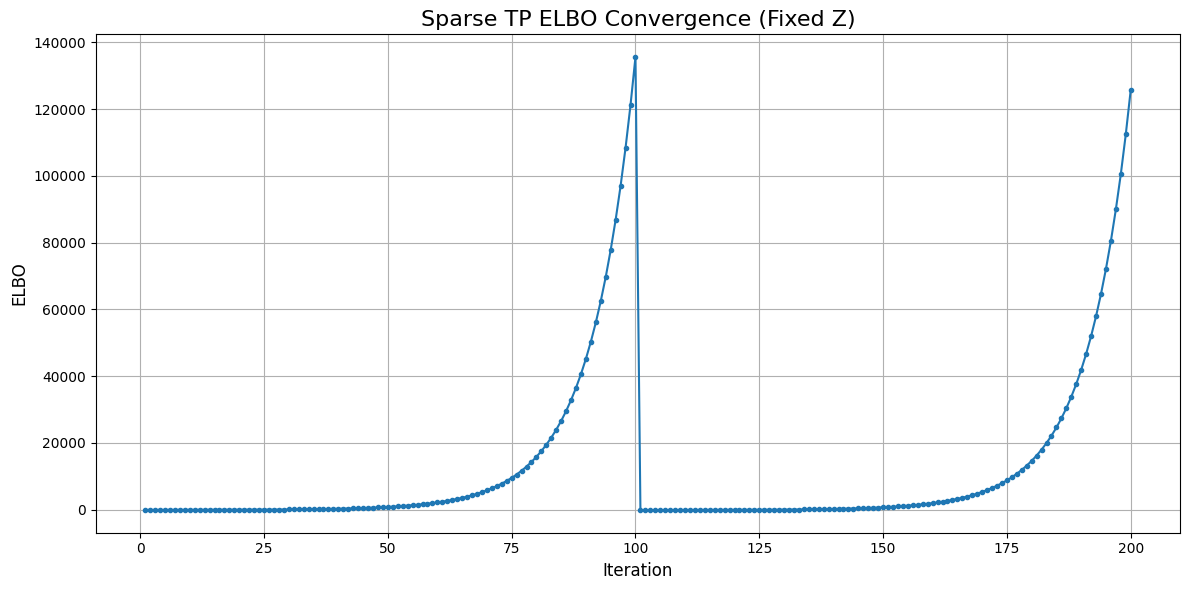

In [6]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
from scipy.stats import t
import tqdm

# Set default tensor type for better performance
torch.set_default_dtype(torch.float64)

class TPRegression(nn.Module):
    """
    Implements the sparse Student-t Process regression model using inducing points.
    This is suitable for larger datasets as it avoids the O(N^3) complexity
    by working with an M x M kernel matrix, where M << N.
    """
    def __init__(self, X, y, Z_initial, nu_f=3.0, nu_e=3.0,
                 kernel_lengthscale=1.0, kernel_variance=1.0, likelihood_sigma=0.1):
        super().__init__()

        # Data is not a parameter
        self.register_buffer('X', X)
        self.register_buffer('y', y)

        self.N, self.D = X.shape
        self.M = Z_initial.shape[0]

        # --- Hyperparameters and Inducing Points ---
        # Z is now a fixed buffer, not a parameter to be optimized.
        self.register_buffer('Z', Z_initial.clone()) # <--- 変更点: nn.Parameter から register_buffer へ

        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance)))
        self.log_likelihood_sigma_sq = nn.Parameter(torch.log(torch.tensor(likelihood_sigma**2)))
        self.log_nu_f = nn.Parameter(torch.log(torch.tensor(nu_f)))
        self.log_nu_e = nn.Parameter(torch.log(torch.tensor(nu_e)))

        # Variational Parameters (not optimized by gradient descent, so not nn.Parameter)
        self.m_u = torch.zeros(self.M, 1)
        self.L_u = torch.eye(self.M)
        self.alpha_r = torch.tensor(1.0)
        self.beta_r = torch.tensor(1.0)
        self.alpha_lambda = torch.ones(self.N, 1)
        self.beta_lambda = torch.ones(self.N, 1)

    def _get_hyperparams(self):
        """Helper to get positive hyperparameters from their log-transformed storage."""
        lengthscale = torch.exp(self.log_kernel_lengthscale)
        variance = torch.exp(self.log_kernel_variance)
        sigma_sq = torch.exp(self.log_likelihood_sigma_sq)
        nu_f = torch.exp(self.log_nu_f)
        nu_e = torch.exp(self.log_nu_e)
        return lengthscale, variance, sigma_sq, nu_f, nu_e

    def kernel(self, A, B):
        """Computes the RBF kernel matrix between A and B."""
        lengthscale, variance, _, _, _ = self._get_hyperparams()
        sq_dist = torch.cdist(A, B, p=2).pow(2)
        return variance * torch.exp(-0.5 * sq_dist / lengthscale.pow(2))

    def _update_q_lambda(self, E_q_f, Var_q_f):
        """CAVI update for q(lambda_i)."""
        _, _, sigma_sq, _, nu_e = self._get_hyperparams()
        self.alpha_lambda = nu_e / 2.0 + 0.5
        expected_sq_error = (self.y - E_q_f).pow(2) + Var_q_f
        self.beta_lambda = nu_e / 2.0 + (1.0 / (2.0 * sigma_sq)) * expected_sq_error

    def _update_q_r(self, E_quad_form_u):
        """CAVI update for q(r)."""
        _, _, _, nu_f, _ = self._get_hyperparams()
        self.alpha_r = nu_f / 2.0 + self.M / 2.0
        self.beta_r = nu_f / 2.0 + 0.5 * E_quad_form_u.squeeze()

    def _update_q_u(self, Kzz, Lzz, Kxz):
        """CAVI update for q(u)."""
        _, _, sigma_sq, _, _ = self._get_hyperparams()
        E_r = self.alpha_r / self.beta_r
        E_lambda = self.alpha_lambda / self.beta_lambda

        Psi = Kxz.T @ (E_lambda * Kxz) / sigma_sq
        B = E_r * Kzz + Psi
        L_B = torch.linalg.cholesky(B)

        Kzz_invB_Kzz = torch.cholesky_solve(Kzz, L_B)
        S_u = Kzz @ Kzz_invB_Kzz
        S_u = 0.5 * (S_u + S_u.T) # Ensure symmetry
        self.L_u = torch.linalg.cholesky(S_u + torch.eye(self.M) * 1e-6)

        temp_vec = (Kxz.T * E_lambda.T) @ self.y / sigma_sq
        m_u_unscaled = torch.cholesky_solve(temp_vec, L_B)
        self.m_u = Kzz @ m_u_unscaled

    def _cavi_step(self, Kzz, Lzz, Kxz, Kxx_diag, cavi_max_iter=10, cavi_tol=1e-5):
        """Runs the inner CAVI loop until convergence for fixed hyperparameters."""
        for _ in range(cavi_max_iter):
            m_u_old = self.m_u.clone()

            # Required expectations for updates
            Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
            E_q_f = Kxz @ Kzz_inv_mu

            E_inv_r = self.beta_r / (self.alpha_r - 1) if self.alpha_r > 1 else self.beta_r

            A = torch.linalg.solve(Kzz, Kxz.T).T
            var_f_inducing = torch.sum((A @ self.L_u)**2, dim=1)
            var_f_prior = E_inv_r * (Kxx_diag - torch.sum(A * Kxz, dim=1))
            Var_q_f = (var_f_prior + var_f_inducing).unsqueeze(1)

            S_u = self.L_u @ self.L_u.T
            Kzz_inv_Su = torch.cholesky_solve(S_u, Lzz)
            trace_term = torch.trace(Kzz_inv_Su)
            quad_form_term = self.m_u.T @ Kzz_inv_mu
            E_quad_form_u = trace_term + quad_form_term

            # CAVI updates
            self._update_q_lambda(E_q_f, Var_q_f)
            self._update_q_r(E_quad_form_u)
            self._update_q_u(Kzz, Lzz, Kxz)

            change = torch.norm(self.m_u - m_u_old) / (torch.norm(m_u_old) + 1e-9)
            if change < cavi_tol:
                break

    def calculate_elbo(self):
        """
        Calculates the Evidence Lower Bound (ELBO).
        This method uses self.Z, self.X, so it's compatible with Z being a parameter.
        It's important that kernel() is called inside, as it will use the current self.Z.
        """
        lengthscale, variance, sigma_sq, nu_f, nu_e = self._get_hyperparams()

        Kzz = self.kernel(self.Z, self.Z) + torch.eye(self.M) * 1e-6
        Lzz = torch.linalg.cholesky(Kzz)
        Kxz = self.kernel(self.X, self.Z)
        Kxx_diag = self.kernel(self.X, self.X).diag()

        # --- 1. Expected Log Likelihood ---
        Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
        E_q_f = Kxz @ Kzz_inv_mu

        E_inv_r = self.beta_r / (self.alpha_r - 1) if self.alpha_r > 1 else self.beta_r

        A = torch.linalg.solve(Kzz, Kxz.T).T
        var_f_inducing = torch.sum((A @ self.L_u)**2, dim=1)
        var_f_prior = E_inv_r * (Kxx_diag - torch.sum(A * Kxz, dim=1))
        Var_q_f = (var_f_prior + var_f_inducing).unsqueeze(1)

        expected_sq_error = (self.y - E_q_f).pow(2) + Var_q_f

        E_lambda = self.alpha_lambda / self.beta_lambda
        E_log_lambda = torch.digamma(self.alpha_lambda) - torch.log(self.beta_lambda)

        e_log_lik = -0.5 * self.N * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * self.N * torch.log(sigma_sq) + \
                    0.5 * torch.sum(E_log_lambda) - \
                    0.5 / sigma_sq * torch.sum(E_lambda * expected_sq_error)

        # --- 2. KL Divergence for u and r ---
        S_u = self.L_u @ self.L_u.T
        E_r = self.alpha_r / self.beta_r
        E_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)

        log_q_u = -0.5 * self.M * torch.log(torch.tensor(2 * torch.pi)) - torch.sum(torch.log(torch.diag(self.L_u))) - 0.5 * self.M
        
        log_q_r = self.alpha_r * torch.log(self.beta_r) - torch.lgamma(self.alpha_r) + \
                  (self.alpha_r - 1) * E_log_r - self.beta_r * E_r

        E_quad_form_u = torch.trace(torch.cholesky_solve(S_u, Lzz)) + self.m_u.T @ torch.cholesky_solve(self.m_u, Lzz)
        log_det_Kzz = 2 * torch.sum(torch.log(torch.diag(Lzz)))
        log_p_u_r = -0.5 * self.M * torch.log(torch.tensor(2 * torch.pi)) - 0.5 * log_det_Kzz + \
                     0.5 * self.M * E_log_r - 0.5 * E_r * E_quad_form_u

        log_p_r = (nu_f / 2) * torch.log(nu_f / 2) - torch.lgamma(nu_f / 2) + \
                  (nu_f / 2 - 1) * E_log_r - (nu_f / 2) * E_r

        kl_u_r = log_q_u + log_q_r - log_p_u_r - log_p_r

        # --- 3. KL Divergence for lambda_i ---
        kl_lambda = torch.lgamma(self.alpha_lambda) - self.alpha_lambda * torch.log(self.beta_lambda) - \
                    (torch.lgamma(nu_e / 2) - (nu_e / 2) * torch.log(nu_e / 2)) - \
                    (self.alpha_lambda - nu_e / 2) * E_log_lambda + \
                    (self.beta_lambda - nu_e / 2) * E_lambda

        kl_lambda_sum = torch.sum(kl_lambda)

        elbo = e_log_lik - kl_u_r - kl_lambda_sum
        return elbo

    def fit(self, max_iter_global=50, max_iter_local=1, lr=0.01, cavi_max_iter=10, cavi_tol=1e-5):
        """
        Fits the model by jointly optimizing hyperparameters (M-step)
        and updating variational parameters (E-step).
        Returns the history of ELBO values.
        """
        elbo_history = [] 

        print("Starting optimization with hyperparameter updates (Z is fixed)...") # <--- 変更点: メッセージを修正
        pbar = tqdm.trange(max_iter_global)
        for i in pbar:
            # --- E-Step: Update variational parameters with fixed hypers/Z ---
            with torch.no_grad():
                Kzz = self.kernel(self.Z, self.Z) + torch.eye(self.M) * 1e-6
                Lzz = torch.linalg.cholesky(Kzz)
                Kxz = self.kernel(self.X, self.Z)
                Kxx_diag = self.kernel(self.X, self.X).diag()
                self._cavi_step(Kzz, Lzz, Kxz, Kxx_diag, cavi_max_iter, cavi_tol)

            optimizer = torch.optim.Adam(self.parameters(), lr=lr)
            for j in range(max_iter_local):
                # --- M-Step: Update hyperparameters by maximizing ELBO ---
                optimizer.zero_grad()
                neg_elbo = -self.calculate_elbo()
                neg_elbo.backward()
                optimizer.step()

                current_elbo = -neg_elbo.item()
                elbo_history.append(current_elbo)
                pbar.set_description(f"ELBO: {current_elbo:.2f}")
        
        return elbo_history 

    def predict(self, X_test):
        """Make predictions at new test points X_test."""
        with torch.no_grad():
            K_star_z = self.kernel(X_test, self.Z)
            K_star_star_diag = self.kernel(X_test, X_test).diag()
            Kzz = self.kernel(self.Z, self.Z) + torch.eye(self.M) * 1e-6
            Lzz = torch.linalg.cholesky(Kzz)

            # Predictive Mean
            Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
            pred_mean = K_star_z @ Kzz_inv_mu

            # Predictive Variance
            S_u = self.L_u @ self.L_u.T
            A_star = torch.linalg.solve(Kzz, K_star_z.T).T
            var_from_q_u = torch.sum((A_star @ self.L_u)**2, dim=1)

            E_inv_r = self.beta_r / (self.alpha_r - 1.0) if self.alpha_r > 1 else self.beta_r
            var_from_prior = E_inv_r * (K_star_star_diag - torch.sum(A_star * K_star_z, dim=1))

            pred_var = var_from_prior + var_from_q_u
            
            # Predictive degrees of freedom
            pred_nu = 2 * self.alpha_r

            return pred_mean.detach(), pred_var.unsqueeze(1).detach(), pred_nu.detach()

if __name__ == '__main__':
    # 1. Generate data
    N = 100
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    noise = torch.randn(N, 1) * 0.1
    t_dist_sample = torch.distributions.StudentT(df=2)
    outlier_noise = t_dist_sample.sample((N, 1)) * 0.5
    y_train = y_true + noise
    outlier_indices = torch.randperm(N)[:10]
    y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
    y_train[30] = -4.0
    y_train[70] = 5.0

    # 2. Setup the model with INITIAL inducing points
    M = 20
    Z_initial = torch.linspace(-5, 5, M).unsqueeze(1)

    model = TPRegression(
        X=X_train,
        y=y_train,
        Z_initial=Z_initial,
        nu_f=5.0,
        nu_e=5.0,
        kernel_lengthscale=0.5,
        kernel_variance=2.0,
        likelihood_sigma=0.5
    )

    # 3. Fit the model and get ELBO history
    elbo_history = model.fit(max_iter_global=2, max_iter_local=100, lr=0.05, cavi_max_iter=200)

    # Print final Z locations (they should be the same as initial)
    print("\n--- Initial Z ---")
    print(Z_initial.squeeze().numpy())
    print("\n--- Final Z (Fixed) ---") # <--- 変更点: メッセージを修正
    print(model.Z.detach().squeeze().numpy())
    print("-------------------")

    # 4. Make predictions
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # 5. Visualize the regression results
    plt.figure(figsize=(12, 8))

    pred_scale = torch.sqrt(pred_var.clamp(min=1e-9))
    df = pred_nu.item()
    lower_quantile = t.ppf(0.025, df=df)
    upper_quantile = t.ppf(0.975, df=df)
    lower = pred_mean + lower_quantile * pred_scale
    upper = pred_mean + upper_quantile * pred_scale

    plt.fill_between(X_test.squeeze(), lower.squeeze(), upper.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval (Student-t)')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', mew=2, label='Training Data (with outliers)')

    # Plot final inducing points
    plt.plot(model.Z.detach(), torch.full_like(model.Z.detach(), -5.5), 'r|', ms=20, label='Fixed Inducing Points') # <--- 変更点: ラベルを修正

    plt.title('Sparse TP Regression (with Fixed Z and Hyperparameter Optimization)', fontsize=16) # <--- 変更点: タイトルを修正
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    
    # 6. Visualize ELBO history
    plt.figure(figsize=(12, 6))
    plt.plot(range(1, len(elbo_history) + 1), elbo_history, marker='.', linestyle='-')
    plt.title('Sparse TP ELBO Convergence (Fixed Z)', fontsize=16) # <--- 変更点: タイトルを修正
    plt.xlabel('Iteration', fontsize=12)
    plt.ylabel('ELBO', fontsize=12)
    plt.grid(True)
    plt.tight_layout()

    plt.show()

Epoch 1000/1000 | ELBO: 16289580156126208000.00: 100%|██████████| 1000/1000 [00:08<00:00, 116.51it/s]


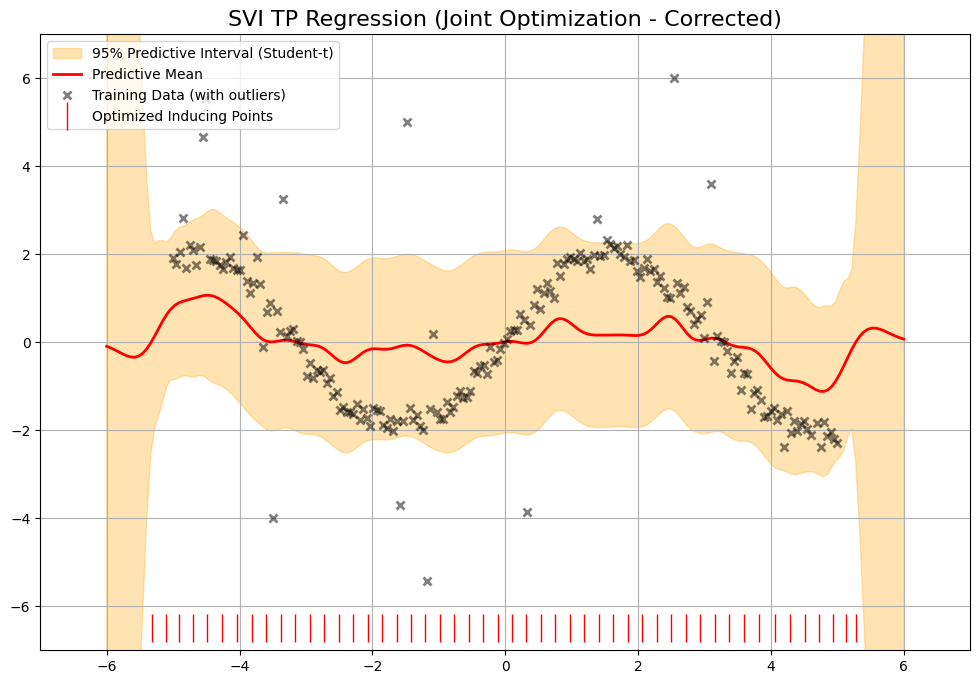

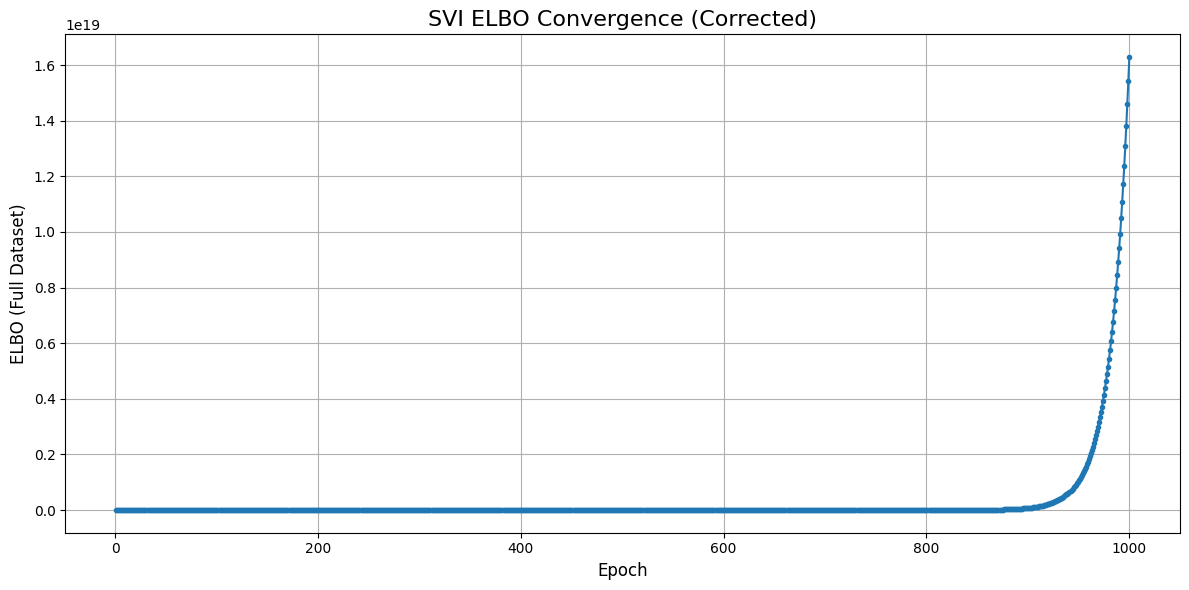

In [12]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
from scipy.stats import t
import tqdm
from torch.utils.data import TensorDataset, DataLoader

# Set default tensor type for better performance
torch.set_default_dtype(torch.float64)

class SVITPRegression(nn.Module):
    """
    Implements the sparse Student-t Process regression model using
    Stochastic Variational Inference (SVI) for joint optimization.
    (Corrected version)
    """
    def __init__(self, N_total, Z_initial, nu_f=3.0, nu_e=3.0,
                 kernel_lengthscale=1.0, kernel_variance=1.0):
        super().__init__()

        self.N_total = N_total
        self.M, self.D = Z_initial.shape

        # --- Model Hyperparameters ---
        self.log_kernel_lengthscale = nn.Parameter(torch.log(torch.tensor(kernel_lengthscale)))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance)))
        self.log_nu_f = nn.Parameter(torch.log(torch.tensor(nu_f)))
        self.log_nu_e = nn.Parameter(torch.log(torch.tensor(nu_e)))

        # --- Inducing Points ---
        self.Z = nn.Parameter(Z_initial.clone())

        # --- Global Variational Parameters ---
        self.m_u = nn.Parameter(torch.zeros(self.M, 1))
        # To ensure S_u is positive semi-definite, we parameterize its Cholesky factor
        self.L_u_chol_flat = nn.Parameter(torch.eye(self.M)[torch.tril_indices(self.M, self.M).unbind()])
        
        # We optimize the log of the Gamma parameters to ensure they remain positive
        self.alpha_r_log = nn.Parameter(torch.log(torch.tensor(5.0)))
        self.beta_r_log = nn.Parameter(torch.log(torch.tensor(5.0)))


    def _get_hyperparams(self):
        """Helper to get positive hyperparameters from their log-transformed storage."""
        lengthscale = torch.exp(self.log_kernel_lengthscale)
        variance = torch.exp(self.log_kernel_variance)
        nu_f = torch.exp(self.log_nu_f)
        nu_e = torch.exp(self.log_nu_e)
        return lengthscale, variance, nu_f, nu_e

    def kernel(self, A, B):
        """Computes the RBF kernel matrix between A and B."""
        lengthscale, variance, _, _ = self._get_hyperparams()
        sq_dist = torch.cdist(A, B, p=2).pow(2)
        return variance * torch.exp(-0.5 * sq_dist / lengthscale.pow(2))

    def calculate_elbo(self, X_batch, y_batch):
        """
        Calculates the SVI estimate of the Evidence Lower Bound (ELBO) for a minibatch.
        """
        n_batch = X_batch.shape[0]
        lengthscale, variance, nu_f, nu_e = self._get_hyperparams()

        # --- Reconstruct Variational and Kernel Matrices ---
        Kzz = self.kernel(self.Z, self.Z) + torch.eye(self.M) * 1e-6
        Lzz = torch.linalg.cholesky(Kzz)
        Kxz_batch = self.kernel(X_batch, self.Z)
        Kxx_batch_diag = self.kernel(X_batch, X_batch).diag()

        L_u = torch.zeros(self.M, self.M, device=self.Z.device)
        L_u[torch.tril_indices(self.M, self.M).unbind()] = self.L_u_chol_flat
        S_u = L_u @ L_u.T
        
        alpha_r = torch.exp(self.alpha_r_log)
        beta_r = torch.exp(self.beta_r_log)

        # --- 1. Compute Expectations needed for the ELBO ---
        E_r = alpha_r / beta_r
        E_log_r = torch.digamma(alpha_r) - torch.log(beta_r)
        E_inv_r = beta_r / (alpha_r - 1) if alpha_r > 1 else beta_r

        Kzz_inv_mu = torch.cholesky_solve(self.m_u, Lzz)
        E_q_f_batch = Kxz_batch @ Kzz_inv_mu

        A_batch = torch.linalg.solve(Kzz, Kxz_batch.T).T
        var_f_inducing = torch.sum((A_batch @ L_u)**2, dim=1)
        var_f_prior = E_inv_r * (Kxx_batch_diag - torch.sum(A_batch * Kxz_batch, dim=1))
        Var_q_f_batch = (var_f_prior + var_f_inducing).unsqueeze(1)

        # --- 2. Infer Local Variational Parameters q(lambda) for the batch ---
        alpha_lambda_batch = nu_e / 2.0 + 0.5
        expected_sq_error_batch = (y_batch - E_q_f_batch).pow(2) + Var_q_f_batch
        beta_lambda_batch = nu_e / 2.0 + 0.5 * expected_sq_error_batch

        E_lambda_batch = alpha_lambda_batch / beta_lambda_batch
        E_log_lambda_batch = torch.digamma(alpha_lambda_batch) - torch.log(beta_lambda_batch)

        # --- 3. Assemble the ELBO ---
        
        # Expected Log Likelihood term (for the batch)
        e_log_lik = -0.5 * n_batch * math.log(2 * math.pi) + \
                    0.5 * torch.sum(E_log_lambda_batch) - \
                    0.5 * torch.sum(E_lambda_batch * expected_sq_error_batch)

        # KL divergence for local variables q(lambda) (for the batch)
        kl_lambda = torch.sum(
            torch.lgamma(alpha_lambda_batch) - (nu_e / 2.0) * torch.log(nu_e / 2.0) + torch.lgamma(nu_e / 2.0) \
            - alpha_lambda_batch * torch.log(beta_lambda_batch) \
            - (alpha_lambda_batch - nu_e / 2.0) * E_log_lambda_batch \
            + (beta_lambda_batch - nu_e / 2.0) * E_lambda_batch
        )

        # KL divergence for global variables q(u) and q(r)
        # These terms are NOT scaled by batch size
        
        # KL[q(u) || p(u|r)] = E_q[log q(u) - log p(u|r)]
        log_det_Kzz = 2 * torch.sum(torch.log(torch.diag(Lzz)))
        E_quad_form_u = torch.trace(torch.cholesky_solve(S_u, Lzz)) + self.m_u.T @ torch.cholesky_solve(self.m_u, Lzz)
        
        # E[log q(u)]
        e_log_q_u = -0.5 * (self.M * math.log(2 * math.pi) + 2 * torch.sum(torch.log(torch.diag(L_u))) + self.M)
        # E[log p(u|r)]
        e_log_p_u_r = -0.5 * (self.M * math.log(2 * math.pi) - self.M * E_log_r + log_det_Kzz + E_r * E_quad_form_u)
        kl_u = e_log_q_u - e_log_p_u_r

        # KL[q(r) || p(r)] = E_q[log q(r) - log p(r)]
        e_log_q_r = (alpha_r - 1) * E_log_r - beta_r * E_r - torch.lgamma(alpha_r) + alpha_r * torch.log(beta_r)
        e_log_p_r = (nu_f / 2.0 - 1) * E_log_r - (nu_f / 2.0) * E_r - torch.lgamma(nu_f / 2.0) + (nu_f / 2.0) * torch.log(nu_f / 2.0)
        kl_r = e_log_q_r - e_log_p_r
        
        # Combine terms, scaling the data-dependent parts
        # ELBO = (Scaled Likelihood) - (Scaled Local KL) - (Global KL)
        elbo = (self.N_total / n_batch) * e_log_lik - (self.N_total / n_batch) * kl_lambda - (kl_u + kl_r)

        return elbo

    def fit(self, X_train, y_train, num_epochs=200, batch_size=64, lr=0.01):
        """
        Fits the model using Stochastic Variational Inference.
        """
        dataset = TensorDataset(X_train, y_train)
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
        
        optimizer = torch.optim.Adam(self.parameters(), lr=lr)
        
        elbo_history = []
        pbar = tqdm.trange(num_epochs)
        
        for epoch in pbar:
            for X_batch, y_batch in dataloader:
                optimizer.zero_grad()
                neg_elbo = -self.calculate_elbo(X_batch, y_batch)
                neg_elbo.backward()
                optimizer.step()

            # Log ELBO at the end of each epoch using the full dataset for a stable metric
            with torch.no_grad():
                epoch_elbo = self.calculate_elbo(X_train, y_train).item()
                elbo_history.append(epoch_elbo)
                pbar.set_description(f"Epoch {epoch+1}/{num_epochs} | ELBO: {epoch_elbo:.2f}")
                
        return elbo_history

    def predict(self, X_test):
        """Make predictions at new test points X_test."""
        with torch.no_grad():
            Z_final = self.Z
            K_star_z = self.kernel(X_test, Z_final)
            K_star_star_diag = self.kernel(X_test, X_test).diag()
            Kzz = self.kernel(Z_final, Z_final) + torch.eye(self.M) * 1e-6
            Lzz = torch.linalg.cholesky(Kzz)

            pred_mean = K_star_z @ torch.cholesky_solve(self.m_u, Lzz)

            L_u = torch.zeros(self.M, self.M, device=self.Z.device)
            L_u[torch.tril_indices(self.M, self.M).unbind()] = self.L_u_chol_flat
            
            A_star = torch.linalg.solve(Kzz, K_star_z.T).T
            var_from_q_u = torch.sum((A_star @ L_u)**2, dim=1)

            alpha_r = torch.exp(self.alpha_r_log)
            beta_r = torch.exp(self.beta_r_log)
            E_inv_r = beta_r / (alpha_r - 1.0) if alpha_r > 1 else beta_r
            var_from_prior = E_inv_r * (K_star_star_diag - torch.sum(A_star * K_star_z, dim=1))

            pred_var = var_from_prior + var_from_q_u
            
            pred_nu = 2 * alpha_r

            return pred_mean.detach(), pred_var.unsqueeze(1).detach(), pred_nu.detach()

if __name__ == '__main__':
    # 1. Generate data
    N = 200
    X_train = torch.linspace(-5, 5, N).unsqueeze(1)
    y_true = torch.sin(X_train) * 2
    noise = torch.randn(N, 1) * 0.2
    t_dist_sample = torch.distributions.StudentT(df=3)
    outlier_noise = t_dist_sample.sample((N, 1)) * 0.5
    y_train = y_true + noise
    outlier_indices = torch.randperm(N)[:20]
    y_train[outlier_indices] += outlier_noise[outlier_indices] * 3
    y_train[30] = -4.0
    y_train[70] = 5.0
    y_train[150] = 6.0

    # 2. Setup the SVI model
    M = 50
    Z_initial = torch.linspace(-5, 5, M).unsqueeze(1)

    model = SVITPRegression(
        N_total=N,
        Z_initial=Z_initial,
        nu_f=5.0,
        nu_e=5.0,
        kernel_lengthscale=0.5,
        kernel_variance=2.0
    )

    # 3. Fit the model using SVI
    elbo_history = model.fit(X_train, y_train, num_epochs=1000, batch_size=200, lr=0.01)

    # 4. Make predictions
    X_test = torch.linspace(-6, 6, 200).unsqueeze(1)
    pred_mean, pred_var, pred_nu = model.predict(X_test)

    # 5. Visualize the regression results
    plt.figure(figsize=(12, 8))

    pred_scale = torch.sqrt(pred_var.clamp(min=1e-9))
    df = pred_nu.item()
    lower_quantile = t.ppf(0.025, df=df)
    upper_quantile = t.ppf(0.975, df=df)
    lower = pred_mean + lower_quantile * pred_scale
    upper = pred_mean + upper_quantile * pred_scale

    plt.fill_between(X_test.squeeze(), lower.squeeze(), upper.squeeze(), color='orange', alpha=0.3, label='95% Predictive Interval (Student-t)')
    plt.plot(X_test, pred_mean, 'r-', lw=2, label='Predictive Mean')
    plt.plot(X_train, y_train, 'kx', alpha=0.5, mew=2, label='Training Data (with outliers)')
    plt.plot(model.Z.detach(), torch.full_like(model.Z.detach(), -6.5), 'r|', ms=20, label='Optimized Inducing Points')

    plt.title('SVI TP Regression (Joint Optimization - Corrected)', fontsize=16)
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.xlim(-7, 7)
    plt.ylim(-7, 7)
    
    # 6. Visualize ELBO history
    plt.figure(figsize=(12, 6))
    plt.plot(range(1, len(elbo_history) + 1), elbo_history, marker='.', linestyle='-')
    plt.title('SVI ELBO Convergence (Corrected)', fontsize=16)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('ELBO (Full Dataset)', fontsize=12)
    plt.grid(True)
    plt.tight_layout()

    plt.show()
